In [14]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [17]:


data_path = r"C:/Users/nitin/Downloads/building-energy-anomaly-detection/data/meters/raw"

files = {
    "electricity.csv": "electricity",
    "chilledwater.csv": "chilled_water",
    "steam.csv": "steam",
    "hotwater.csv": "hot_water",
    "irrigation.csv": "irrigation",
    "solar.csv": "solar",
    "gas.csv": "gas",
    "water.csv": "water"
}

df_final = None

for file, meter in files.items():

    print("  ", file)

    temp = pd.read_csv(os.path.join(data_path, file))

    temp['timestamp'] = pd.to_datetime(temp['timestamp'])

   
    energy_cols = temp.columns.drop('timestamp')
    temp[meter] = temp[energy_cols].sum(axis=1)

    temp = temp[['timestamp', meter]]

    if df_final is None:
        df_final = temp
    else:
        df_final = pd.merge(df_final, temp,
                            on="timestamp",
                            how="outer")

# Cleaning
df_final = df_final.sort_values("timestamp")
df_final = df_final.drop_duplicates()
df_final = df_final.fillna(0)

print("\n CLEAN DATA READY")
print(df_final.shape)

df_final.head()


   electricity.csv
   chilledwater.csv
   steam.csv
   hotwater.csv
   irrigation.csv
   solar.csv
   gas.csv
   water.csv

 CLEAN DATA READY
(17544, 9)


,timestamp,electricity,chilled_water,steam,hot_water,irrigation,solar,gas,water
0,2016-01-01 00:00:00,142436.7732,1.166536e+07,1.217716e+06,9.962410e+06,17.0660,198.9966,68588.8224,74285.8850
1,2016-01-01 01:00:00,163826.3551,1.059462e+07,1.229928e+06,1.065427e+07,383.8122,134.4800,66788.4616,73006.3692
2,2016-01-01 02:00:00,164064.4742,1.038123e+07,3.154092e+05,1.105221e+07,41.0970,135.4833,64279.6734,74208.3193
3,2016-01-01 03:00:00,164156.6057,9.709122e+06,2.419218e+05,1.059985e+07,8602.5745,202.0166,64607.8160,74553.4443
4,2016-01-01 04:00:00,164670.6359,9.147226e+06,2.916289e+05,1.168208e+07,6471.4424,137.4600,66342.1532,75399.9847


In [18]:
#  DATA OVERVIEW 

print(" Shape of Dataset:")
print(df_final.shape)

print("\n Column Names:")
print(df_final.columns)

print("\n Dataset Info:")
df_final.info()

print("\n Statistical Summary:")
display(df_final.describe())

print("\n First 5 Rows:")
display(df_final.head())

print("\n Missing Values:")
print(df_final.isnull().sum())

 Shape of Dataset:
(17544, 9)

 Column Names:
Index(['timestamp', 'electricity', 'chilled_water', 'steam', 'hot_water',
       'irrigation', 'solar', 'gas', 'water'],
      dtype='object')

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      17544 non-null  datetime64[ns]
 1   electricity    17544 non-null  float64       
 2   chilled_water  17544 non-null  float64       
 3   steam          17544 non-null  float64       
 4   hot_water      17544 non-null  float64       
 5   irrigation     17544 non-null  float64       
 6   solar          17544 non-null  float64       
 7   gas            17544 non-null  float64       
 8   water          17544 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 1.2 MB

 Statistical Summary:


,timestamp,electricity,chilled_water,steam,hot_water,irrigation,solar,gas,water
count,17544,17544.000000,1.754400e+04,1.754400e+04,1.754400e+04,17544.000000,17544.000000,17544.000000,17544.000000
mean,2016-12-31 11:30:00,215480.391269,2.513395e+07,7.446646e+05,7.503524e+06,11684.935499,120.813212,105608.511597,72261.360438
min,2016-01-01 00:00:00,142436.773200,1.484936e+05,5.409901e+04,3.264612e+05,7.135600,4.040000,35136.184900,6872.276800
25%,2016-07-01 17:45:00,190970.258475,1.015220e+07,1.099250e+05,4.378463e+06,536.935200,38.390000,70656.346425,48860.620575
50%,2016-12-31 11:30:00,208819.334400,1.998888e+07,1.628429e+05,5.980586e+06,3832.400150,81.270000,96792.155100,68227.641400
75%,2017-07-02 05:15:00,238942.666800,3.832128e+07,2.933174e+05,9.924995e+06,16970.928375,208.982675,130342.319200,95558.108075
max,2017-12-31 23:00:00,488566.689500,7.601573e+07,6.830530e+06,2.409563e+07,112182.664000,2457.920300,411665.888300,416150.418600
std,NaN,29735.502504,1.633639e+07,1.464772e+06,4.078813e+06,16220.110192,100.019277,43357.155745,35354.734886



 First 5 Rows:


,timestamp,electricity,chilled_water,steam,hot_water,irrigation,solar,gas,water
0,2016-01-01 00:00:00,142436.7732,1.166536e+07,1.217716e+06,9.962410e+06,17.0660,198.9966,68588.8224,74285.8850
1,2016-01-01 01:00:00,163826.3551,1.059462e+07,1.229928e+06,1.065427e+07,383.8122,134.4800,66788.4616,73006.3692
2,2016-01-01 02:00:00,164064.4742,1.038123e+07,3.154092e+05,1.105221e+07,41.0970,135.4833,64279.6734,74208.3193
3,2016-01-01 03:00:00,164156.6057,9.709122e+06,2.419218e+05,1.059985e+07,8602.5745,202.0166,64607.8160,74553.4443
4,2016-01-01 04:00:00,164670.6359,9.147226e+06,2.916289e+05,1.168208e+07,6471.4424,137.4600,66342.1532,75399.9847



 Missing Values:
timestamp        0
electricity      0
chilled_water    0
steam            0
hot_water        0
irrigation       0
solar            0
gas              0
water            0
dtype: int64


In [20]:
#  FEATURE ENGINEERING

df_fe = df_final.copy()

df_fe['hour'] = df_fe['timestamp'].dt.hour
df_fe['day'] = df_fe['timestamp'].dt.day
df_fe['month'] = df_fe['timestamp'].dt.month
df_fe['day_of_week'] = df_fe['timestamp'].dt.dayofweek

df_fe['is_weekend'] = df_fe['day_of_week'].isin([5,6]).astype(int)

energy_cols = df_fe.columns.drop('timestamp')
df_fe['total_energy'] = df_fe[energy_cols].sum(axis=1)

df_fe['rolling_mean_24h'] = df_fe['total_energy'].rolling(window=24).mean()

df_fe['energy_diff'] = df_fe['total_energy'].diff()

df_fe = df_fe.fillna(0)

print(" Feature Engineering Completed")
print(df_fe.shape)

df_fe.head()

 Feature Engineering Completed
(17544, 17)


,timestamp,electricity,chilled_water,steam,hot_water,irrigation,solar,gas,water,hour,day,month,day_of_week,is_weekend,total_energy,rolling_mean_24h,energy_diff
0,2016-01-01 00:00:00,142436.7732,1.166536e+07,1.217716e+06,9.962410e+06,17.0660,198.9966,68588.8224,74285.8850,0,1,1,4,0,2.313102e+07,0.0,0.000000e+00
1,2016-01-01 01:00:00,163826.3551,1.059462e+07,1.229928e+06,1.065427e+07,383.8122,134.4800,66788.4616,73006.3692,1,1,1,4,0,2.278297e+07,0.0,-3.480510e+05
2,2016-01-01 02:00:00,164064.4742,1.038123e+07,3.154092e+05,1.105221e+07,41.0970,135.4833,64279.6734,74208.3193,2,1,1,4,0,2.205158e+07,0.0,-7.313856e+05
3,2016-01-01 03:00:00,164156.6057,9.709122e+06,2.419218e+05,1.059985e+07,8602.5745,202.0166,64607.8160,74553.4443,3,1,1,4,0,2.086303e+07,0.0,-1.188551e+06
4,2016-01-01 04:00:00,164670.6359,9.147226e+06,2.916289e+05,1.168208e+07,6471.4424,137.4600,66342.1532,75399.9847,4,1,1,4,0,2.143397e+07,0.0,5.709354e+05


In [21]:
# timestamp sodun sagle features ghe
X = df_fe.drop(columns=['timestamp'])

# Scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [22]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,   # 1% anomalies
    random_state=42
)

df_fe['anomaly'] = iso_forest.fit_predict(X_scaled)

In [23]:
df_fe['anomaly'] = df_fe['anomaly'].map({1:0, -1:1})


In [24]:
df_fe['anomaly'].value_counts()

anomaly
0    17368
1      176
Name: count, dtype: int64

In [25]:
df_fe[df_fe['anomaly']==1].head()

,timestamp,electricity,chilled_water,steam,hot_water,irrigation,solar,gas,water,hour,day,month,day_of_week,is_weekend,total_energy,rolling_mean_24h,energy_diff,anomaly
311,2016-01-13 23:00:00,169959.6677,1.484936e+05,1.076314e+06,1.334676e+06,837.0464,234.0207,130410.8238,106114.9451,23,13,1,2,0,2.967079e+06,2.623016e+07,-2.414139e+07,1
446,2016-01-19 14:00:00,262170.3415,8.683532e+06,3.898421e+05,2.139836e+07,1241.7351,189.0525,232760.9854,164949.6044,14,19,1,1,0,3.113308e+07,2.863843e+07,-8.532901e+04,1
660,2016-01-28 12:00:00,272343.3551,1.102027e+07,4.723716e+05,1.864796e+07,105.5791,143.2874,206957.4501,165160.5553,12,28,1,3,0,3.078535e+07,2.536844e+07,3.262949e+06,1
667,2016-01-28 19:00:00,222917.9307,2.977760e+05,1.244097e+06,1.127157e+06,113.4876,179.4600,171636.3340,131688.9502,19,28,1,3,0,3.195617e+06,2.524101e+07,-2.337823e+07,1
1332,2016-02-25 12:00:00,247306.0547,2.546965e+05,6.346731e+05,7.896916e+05,2278.2593,186.0100,245554.7503,153839.0358,12,25,2,3,0,2.328267e+06,2.269301e+07,-2.033471e+07,1


In [26]:
from sklearn.preprocessing import StandardScaler

# timestamp & anomaly sodun
features = df_fe.drop(columns=['timestamp','anomaly'])

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

# dataframe madhe convert
df_scaled = pd.DataFrame(
    scaled_data,
    columns=features.columns
)

print("Feature Scaling Done")
df_scaled.head()

Feature Scaling Done


,electricity,chilled_water,steam,hot_water,irrigation,solar,gas,water,hour,day,month,day_of_week,is_weekend,total_energy,rolling_mean_24h,energy_diff
0,-2.456515,-0.824477,0.322961,0.602861,-0.719366,0.781705,-0.853855,0.057265,-1.661325,-1.674108,-1.600161,0.495731,-0.634879,-0.763589,-2.642841,-0.000093
1,-1.737166,-0.890022,0.331299,0.772489,-0.696755,0.136645,-0.895381,0.021073,-1.516862,-1.674108,-1.600161,0.495731,-0.634879,-0.788529,-2.642841,-0.114475
2,-1.729158,-0.903084,-0.293061,0.870053,-0.717885,0.146677,-0.953246,0.055071,-1.372399,-1.674108,-1.600161,0.495731,-0.634879,-0.840938,-2.642841,-0.240452
3,-1.726060,-0.944227,-0.343232,0.759147,-0.190039,0.811901,-0.945677,0.064833,-1.227936,-1.674108,-1.600161,0.495731,-0.634879,-0.926104,-2.642841,-0.390693
4,-1.708772,-0.978624,-0.309296,1.024483,-0.321431,0.166441,-0.905675,0.088778,-1.083473,-1.674108,-1.600161,0.495731,-0.634879,-0.885193,-2.642841,0.187537


In [27]:
df_scaled.describe()

,electricity,chilled_water,steam,hot_water,irrigation,solar,gas,water,hour,day,month,day_of_week,is_weekend,total_energy,rolling_mean_24h,energy_diff
count,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04,17544.000000,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04,1.754400e+04
mean,1.587624e-16,9.072137e-17,7.776117e-17,2.268034e-16,-9.720147e-18,1.555223e-16,2.462437e-16,0.000000,-3.746307e-18,-4.860073e-17,1.296020e-16,9.436643e-17,-1.129967e-16,-2.851243e-16,6.350496e-16,-1.134017e-17
std,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00
min,-2.456515e+00,-1.529479e+00,-4.714626e-01,-1.759646e+00,-7.199786e-01,-1.167540e+00,-1.625437e+00,-1.849567,-1.661325e+00,-1.674108e+00,-1.600161e+00,-1.503602e+00,-6.348787e-01,-2.312084e+00,-2.642841e+00,-1.961723e+01
25%,-8.242952e-01,-9.171044e-01,-4.333492e-01,-7.661912e-01,-6.873146e-01,-8.240967e-01,-8.061682e-01,-0.661903,-8.306624e-01,-8.790077e-01,-7.304823e-01,-1.003769e+00,-6.348787e-01,-8.028222e-01,-8.218048e-01,-4.051931e-01
50%,-2.240166e-01,-3.149541e-01,-3.972210e-01,-3.733883e-01,-4.841372e-01,-3.953672e-01,-2.033484e-01,-0.114096,0.000000e+00,2.967836e-02,1.391961e-01,-4.102599e-03,-6.348787e-01,-3.672635e-01,-4.254182e-01,-8.266456e-03
75%,7.890549e-01,8.072595e-01,-3.081436e-01,5.936876e-01,3.259006e-01,8.815498e-01,5.704828e-01,0.658962,8.306624e-01,8.247787e-01,1.008875e+00,9.955640e-01,1.575104e+00,7.408953e-01,8.186092e-01,3.954887e-01
max,9.184109e+00,3.114717e+00,4.154940e+00,4.067991e+00,6.196049e+00,2.336723e+01,7.059183e+00,9.727095,1.661325e+00,1.733465e+00,1.588660e+00,1.495397e+00,1.575104e+00,3.374674e+00,2.832865e+00,2.118669e+01


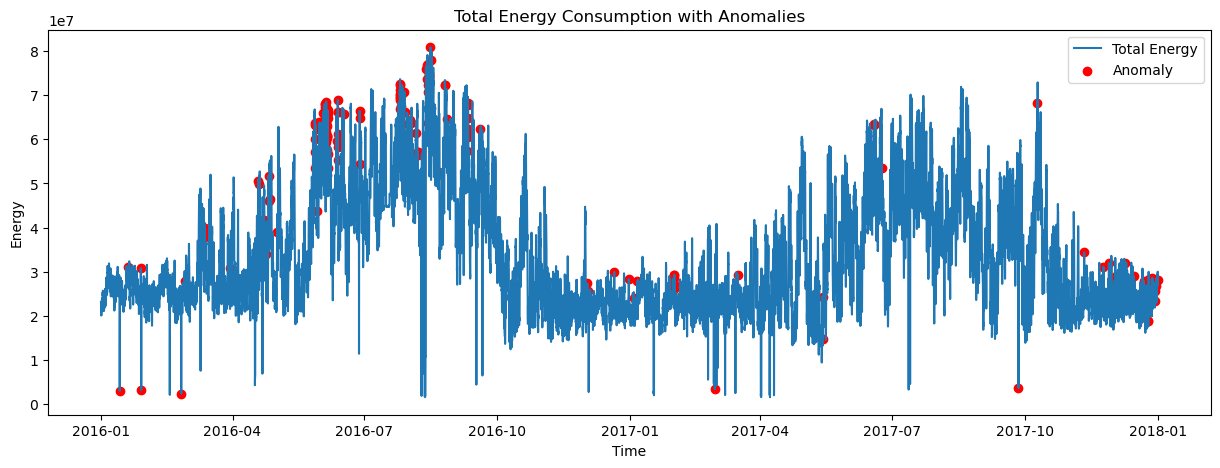

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# Normal energy line
plt.plot(df_fe['timestamp'],
         df_fe['total_energy'],
         label="Total Energy")

# Anomaly points
anomalies = df_fe[df_fe['anomaly'] == 1]

plt.scatter(anomalies['timestamp'],
            anomalies['total_energy'],
            color='red',
            label='Anomaly')

plt.title("Total Energy Consumption with Anomalies")
plt.xlabel("Time")
plt.ylabel("Energy")

plt.legend()
plt.show()

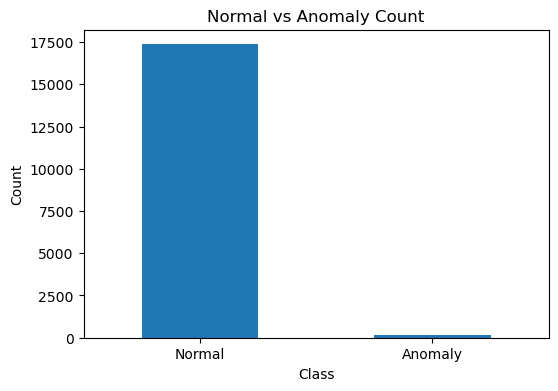

In [31]:
import matplotlib.pyplot as plt

df_fe['anomaly'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Normal vs Anomaly Count")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks([0,1], ['Normal','Anomaly'], rotation=0)

plt.show()

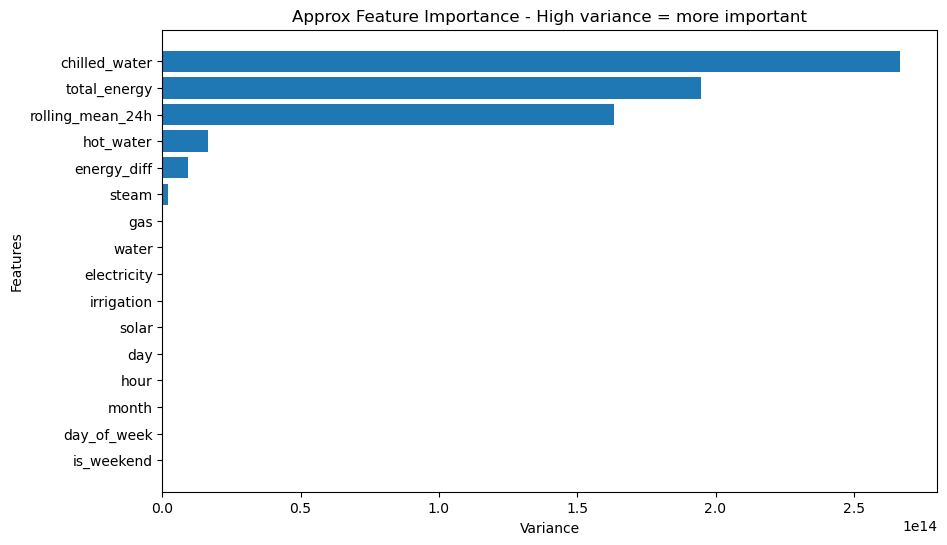

In [34]:
X_features = df_fe.drop(columns=['timestamp','anomaly'])

variances = X_features.var().sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(variances.index, variances.values)
plt.title("Approx Feature Importance - High variance = more important")
plt.xlabel("Variance")
plt.ylabel("Features")
plt.show()

In [36]:
df_fe.to_csv("energy_anomaly_output.csv", index=False)

print(" File Saved Successfully")

 File Saved Successfully


In [38]:
# Assume df_fe already has anomalies detected

unit_cost = 28495  # tu change kar if needed
estimated_cost = df_fe[df_fe['anomaly']==1]['total_energy'].sum() * 1  # direct unit cost multiplier
print(f"Estimated cost from anomalies: ${estimated_cost:,.0f}")

# Anomalies by month
monthly_anomalies = df_fe[df_fe['anomaly']==1].groupby('month').size()
print("\nAnomalies by month:")
print(monthly_anomalies)

#  Peak hours
peak_hours = df_fe[df_fe['anomaly']==1].groupby('hour').size()
print("\nPeak hours:")
print(peak_hours)

# Anomaly types (define spikes & drops using energy_diff)
df_fe['anomaly_type'] = 'Normal'
df_fe.loc[(df_fe['anomaly']==1) & (df_fe['energy_diff']>0), 'anomaly_type'] = 'Spike'
df_fe.loc[(df_fe['anomaly']==1) & (df_fe['energy_diff']<0), 'anomaly_type'] = 'Drop'

anomaly_types = df_fe[df_fe['anomaly']==1].groupby('anomaly_type').size().rename('count')
print("\nAnomaly types:")
print(anomaly_types)

Estimated cost from anomalies: $9,269,698,733

Anomalies by month:
month
1     12
2      3
3      6
4      8
5     16
6     52
7     16
8     31
9      8
10     1
11     4
12    19
dtype: int64

Peak hours:
hour
0     19
1     17
2     10
3     14
4      5
5      3
6      2
7      2
8      1
9      1
10     5
11     3
12     7
13     4
14    10
15     9
16     3
17     4
18     4
19     7
20     7
21     7
22    15
23    17
dtype: int64

Anomaly types:
anomaly_type
Drop     77
Spike    99
Name: count, dtype: int64
